# Regressão Linear

## 1. Introdução

A Regressão Linear é uma técnica estatística e de **Machine Learning Supervisionado** usada para modelar a relação entre uma variável resposta e uma ou mais variáveis de entrada. O modelo representa essa relação por uma função linear e estima o comportamento médio dos dados, que podem conter variação e ruído.

Neste material, o foco está na estimação dos parâmetros da reta, na interpretação dos resultados e nos cuidados necessários para utilizá-la.

## 2. O problema que queremos resolver

Em um problema de regressão, a variável que desejamos prever é numérica e é chamada de **variável resposta**, **variável dependente** ou $y$. As entradas usadas na previsão são as **variáveis explicativas**, **variáveis independentes**, **atributos** ou **features**.

A pergunta central é: **como as variáveis de entrada estão associadas ao valor esperado de $y$?** Uma associação encontrada pelo modelo não prova, por si só, uma relação de causa e efeito.

### 2.1. Regressão versus classificação

A Regressão Linear prevê valores quantitativos, como uma temperatura. A classificação escolhe entre categorias, como “aprovado” e “reprovado”; seus objetivos e formas de avaliação são diferentes.

## 3. Regressão Linear Simples

Na Regressão Linear Simples, há uma variável explicativa. O modelo populacional pode ser representado por:

$$\Large
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$

Depois de estimar os parâmetros com os dados, a previsão do modelo ajustado é representada por:

$$\Large
\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i
$$

- $x_i$: entrada da observação $i$;
- $y_i$: valor observado;
- $\hat{y}_i$: valor previsto pelo modelo ajustado;
- $\beta_0$ e $\beta_1$: parâmetros populacionais, geralmente desconhecidos;
- $\hat{\beta}_0$ e $\hat{\beta}_1$: estimativas dos parâmetros obtidas a partir dos dados;
- $\varepsilon_i$: erro aleatório da observação $i$.

O treinamento consiste em estimar $\beta_0$ e $\beta_1$, obtendo $\hat{\beta}_0$ e $\hat{\beta}_1$. O símbolo chapéu indica uma quantidade estimada a partir da amostra.

### 3.1. Interpretação dos coeficientes

Considere, em milhares de reais, a reta estimada:

$$\Large
\widehat{valor} = 120 + 4{,}5 \times área
$$

O intercepto estimado $\hat{\beta}_0=120$ é a previsão quando a área é zero, e $\hat{\beta}_1=4{,}5$ indica um aumento médio previsto de $4{,}5$ mil reais por unidade adicional de área. Para $área=50$, a previsão é $345$ mil reais. A interpretação deve considerar as unidades e evitar extrapolação para fora do intervalo observado.

## 4. Regressão Linear Múltipla

Com duas ou mais variáveis explicativas, o modelo populacional é:

$$\Large
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip} + \varepsilon_i
$$

Depois que os parâmetros são estimados com os dados, a previsão do modelo ajustado é:

$$\Large
\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_{i1} + \hat{\beta}_2 x_{i2} + \cdots + \hat{\beta}_p x_{ip}
$$

Cada coeficiente estimado representa a mudança prevista em $y$ para uma unidade de aumento na variável correspondente, **mantendo as demais constantes**. Essa interpretação exige cautela quando as variáveis explicativas são muito relacionadas entre si.

### 4.1. Forma matricial

Para várias variáveis explicativas, organizamos os dados em uma matriz $X$, os parâmetros em um vetor $\boldsymbol{\beta}$ e as respostas em um vetor $\mathbf{y}$. A primeira coluna de $X$ contém 1s para representar o intercepto:

$$\Large
X = \begin{bmatrix}
1 & x_{11} & \cdots & x_{1p} \\
1 & x_{21} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & \cdots & x_{np}
\end{bmatrix},
\qquad
\boldsymbol{\beta} = \begin{bmatrix}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_p
\end{bmatrix},
\qquad
\mathbf{y} = \begin{bmatrix}
 y_1 \\
 y_2 \\
 \vdots \\
 y_n
\end{bmatrix}
$$

Com essa organização, o modelo populacional pode ser escrito como:

$$\Large
\mathbf{y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

Após o ajuste, as previsões são calculadas usando os coeficientes estimados:

$$\Large
\hat{\mathbf{y}} = X\hat{\boldsymbol{\beta}}
$$

A função de custo dos mínimos quadrados, escrita para um vetor genérico de parâmetros, pode ser escrita como:

$$\Large
SSE(\boldsymbol{\beta}) = (\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta})
$$

Quando $X^TX$ é invertível, a solução estimada dos mínimos quadrados é:

$$\Large
\boxed{\hat{\boldsymbol{\beta}}=(X^TX)^{-1}X^T\mathbf{y}}
$$

Essa expressão é a versão matricial da mesma ideia usada na regressão simples: escolher os parâmetros que minimizam a soma dos quadrados dos resíduos. Na prática, métodos baseados em QR ou SVD costumam ser preferidos à inversão explícita de $X^TX$, por oferecerem maior estabilidade numérica.

### 4.2. Regularização

A **regularização** é uma técnica usada para reduzir o sobreajuste (*overfitting*) e controlar a complexidade do modelo. Ela acrescenta uma penalização à função de custo, evitando que os coeficientes assumam valores excessivamente grandes apenas para se ajustarem aos dados de treinamento.

Na regressão múltipla, a função regularizada combina o erro de previsão com um termo que depende dos coeficientes:

$$\Large
\text{custo} = SSE(\boldsymbol{\beta}) + \lambda\,\text{penalização}(\boldsymbol{\beta})
$$

O hiperparâmetro $\lambda \geq 0$ controla a intensidade da regularização:

- $\lambda=0$: não há penalização e obtemos a regressão por mínimos quadrados;
- valores maiores de $\lambda$: os coeficientes são mais reduzidos, o que pode diminuir a variância do modelo;
- um valor excessivo de $\lambda$: pode simplificar demais o modelo e causar subajuste (*underfitting*).

Em geral, as variáveis explicativas devem ser padronizadas antes da regularização, especialmente quando estão em escalas diferentes. O intercepto $\beta_0$ normalmente não é penalizado. O valor de $\lambda$ deve ser escolhido usando validação, como validação cruzada, e não com base apenas no desempenho nos dados de treinamento.

#### 4.2.1. Lasso (regularização L1)

A regressão **Lasso** (*Least Absolute Shrinkage and Selection Operator*) usa a soma dos valores absolutos dos coeficientes como penalização, conhecida como norma L1:

$$\Large
\hat{\boldsymbol{\beta}}_{L1} = \underset{\boldsymbol{\beta}}{\operatorname{argmin}}\left\{
SSE(\boldsymbol{\beta}) + \lambda\sum_{j=1}^{p}|\beta_j|
\right\}
$$

A penalização L1 tende a fazer alguns coeficientes ficarem exatamente iguais a zero. Por isso, além de reduzir a complexidade, o Lasso pode realizar **seleção de variáveis**, produzindo um modelo mais esparso e fácil de interpretar.

Essa característica é útil quando há muitas variáveis explicativas e se espera que apenas parte delas seja relevante. Porém, quando existem variáveis muito correlacionadas, o Lasso pode escolher uma delas de forma instável ou distribuir a seleção de maneira pouco previsível.

#### 4.2.2. Ridge (regularização L2)

A regressão **Ridge** usa a soma dos quadrados dos coeficientes como penalização, conhecida como norma L2:

$$\Large
\hat{\boldsymbol{\beta}}_{L2} = \underset{\boldsymbol{\beta}}{\operatorname{argmin}}\left\{
SSE(\boldsymbol{\beta}) + \lambda\sum_{j=1}^{p}\beta_j^2
\right\}
$$

A penalização L2 reduz os coeficientes em direção a zero, mas normalmente não os torna exatamente zero. Assim, o Ridge mantém todas as variáveis no modelo e costuma ser uma escolha estável quando as variáveis explicativas são correlacionadas ou quando há muitas delas.

Quando a função de custo é definida com a soma dos quadrados dos resíduos e o intercepto não é penalizado, a solução do Ridge pode ser expressa por:

$$\Large
\boxed{\hat{\boldsymbol{\beta}}_{Ridge}=(X^TX+\lambda I)^{-1}X^T\mathbf{y}}
$$

Para o Lasso, em geral não há uma fórmula matricial fechada equivalente; a solução é obtida por métodos de otimização numérica.

#### 4.2.3 Lasso e Ridge: principais diferenças

- **Lasso (L1)**: pode zerar coeficientes e selecionar variáveis, gerando modelos esparsos.
- **Ridge (L2)**: reduz os coeficientes sem normalmente zerá-los, sendo mais estável diante de multicolinearidade.
- **Elastic Net**: combina as penalizações L1 e L2 e pode ser útil quando se deseja seleção de variáveis, mas existem grupos de variáveis correlacionadas.

A escolha entre Lasso e Ridge deve ser avaliada por validação cruzada, considerando o desempenho preditivo, a interpretabilidade desejada e a relação entre as variáveis explicativas.

#### 4.2.4. Quando usar a Regularização

A Regularização é recomendada quando o modelo apresenta sinais de sobreajuste (overfitting), quando há muitas variáveis em relação ao número de observações ou quando existe multicolinearidade. Nesses casos, reduzir os coeficientes pode melhorar a generalização para dados novos, mesmo que o erro nos dados de treinamento aumente ligeiramente.

Ela também é útil quando o objetivo principal é a previsão e há incerteza sobre quais variáveis realmente contribuem para o resultado. O Ridge costuma ser uma boa escolha quando se deseja manter todas as variáveis; o Lasso pode ser preferido quando a seleção de variáveis é importante.

A regularização pode não ser necessária quando o conjunto de dados é grande em relação ao número de variáveis, o modelo não apresenta sobreajuste e os coeficientes são estáveis. Ela também deve ser usada com cautela quando a interpretação dos coeficientes sem penalização é essencial, pois a penalização altera suas estimativas e pode dificultar comparações diretas com efeitos estimados por mínimos quadrados.

Não se deve decidir pelo uso ou pela intensidade da regularização observando apenas o desempenho nos dados de treinamento. O procedimento adequado é comparar modelos com e sem regularização em um conjunto de validação ou por validação cruzada, mantendo um conjunto de teste separado para a avaliação final.

## 5. Como os melhores parâmetros são estimados?

Os dados observados raramente ficam perfeitamente sobre uma reta. Para cada observação, comparamos o valor real $y_i$ com o valor previsto pelo modelo ajustado $\hat{y}_i$. A diferença entre eles é chamada de **resíduo**:

$$\Large
 e_i = y_i - \hat{y}_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i)
$$

A ideia de “melhor reta” precisa ser transformada em um critério matemático. Na Regressão Linear, usamos o método dos **mínimos quadrados**: buscamos os valores estimados $\hat{\beta}_0$ e $\hat{\beta}_1$ que tornam a soma dos quadrados dos resíduos a menor possível.

Em muitas aplicações, também se considera que os erros aleatórios do modelo seguem aproximadamente uma distribuição normal, hipótese importante para fazer inferência estatística, como intervalos de confiança e testes. Essa suposição não é necessária para calcular a reta pelos mínimos quadrados e deve ser verificada nos resíduos.

### 5.1. Construção da função de custo

Usando diretamente os coeficientes estimados, o resíduo da observação $i$ é:

$$\Large
 e_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i)
$$

A função que queremos minimizar (**função de custo**) é a soma dos erros quadráticos, também chamada de SSE (*Sum of Squared Errors*):

$$\Large
SSE(\hat{\beta}_0, \hat{\beta}_1) = \sum_{i=1}^{n}\left[y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i)\right]^2
$$

Formalmente, a otimização procura os valores de $\beta_0$ e $\beta_1$ que minimizam a função; os chapéus identificam os valores encontrados nesse mínimo:

$$\Large
(\hat{\beta}_0, \hat{\beta}_1) = \underset{\beta_0,\beta_1}{\operatorname{argmin}}\; SSE(\beta_0,\beta_1)
$$

Essa função recebe um par de parâmetros e devolve o custo correspondente. Portanto, cada escolha de intercepto e inclinação produz uma reta diferente e um valor diferente de SSE.

Elevamos os resíduos ao quadrado por três razões principais:

1. erros positivos e negativos não se cancelam;
2. a função fica diferenciável, permitindo encontrar seu mínimo com cálculo;
3. erros grandes recebem uma penalização maior.

O chapéu nos parâmetros indica os valores estimados a partir dos dados. Nas equações de derivação abaixo, eles aparecem diretamente porque estamos escrevendo a condição satisfeita pelos coeficientes ajustados, como no exemplo do print.

### 5.2. Encontrando o intercepto com derivadas

Para encontrar o intercepto estimado, derivamos a SSE em relação a $\hat{\beta}_0$ e igualamos a derivada a zero:

$$\Large
\frac{\partial SSE}{\partial \hat{\beta}_0} = -2\sum_{i=1}^{n}\left[y_i - (\hat{\beta}_0 + \hat{\beta}_1x_i)\right] = 0
$$

Reorganizando:

$$\Large
\sum_{i=1}^{n}y_i = n\hat{\beta}_0 + \hat{\beta}_1\sum_{i=1}^{n}x_i
$$

Dividindo por $n$ e usando as médias $\bar{x}$ e $\bar{y}$ obtidas dos dados reais:

$$\Large
\bar{y} = \hat{\beta}_0 + \hat{\beta}_1\bar{x}
$$

Logo, o melhor intercepto, depois que a inclinação é conhecida, é:

$$\Large
\boxed{\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}}
$$

Em que $\bar{x}$ e $\bar{y}$ são, respectivamente, as médias das entradas e das respostas.

### 5.3. Encontrando a inclinação com derivadas

Agora derivamos a função de custo em relação à inclinação estimada:

$$\Large
\frac{\partial SSE}{\partial \hat{\beta}_1} = -2\sum_{i=1}^{n}x_i\left[y_i - (\hat{\beta}_0 + \hat{\beta}_1x_i)\right] = 0
$$

Substituindo a relação $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$ e reorganizando os termos, obtemos:

$$\Large
\boxed{\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n}(x_i-\bar{x})^2}}
$$

Essa expressão pode ser entendida intuitivamente:

- o numerador mede se $x$ e $y$ variam juntos;
- o denominador mede quanto $x$ varia;
- se valores altos de $x$ tendem a acompanhar valores altos de $y$, a inclinação tende a ser positiva;
- se valores altos de $x$ tendem a acompanhar valores baixos de $y$, a inclinação tende a ser negativa;
- se $x$ quase não varia, o denominador fica pequeno e a estimativa se torna instável.

Depois de calcular $\hat{\beta}_1$, usamos $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$ para obter o intercepto. Assim, os dois parâmetros são determinados diretamente pelas médias e pelos desvios em relação às médias.

### 5.4. Exemplo numérico passo a passo

Considere os seguintes dados, em que $x$ representa horas de estudo e $y$ representa a nota:

| Estudante | $x$ | $y$ |
|---|---:|---:|
| A | 1 | 2 |
| B | 2 | 3 |
| C | 3 | 5 |

**Passo 1: calcular as médias**

$$\Large
\bar{x} = \frac{1+2+3}{3}=2
\qquad
\bar{y} = \frac{2+3+5}{3}=\frac{10}{3}
$$

**Passo 2: calcular os desvios e seus produtos**

| $x_i-\bar{x}$ | $y_i-\bar{y}$ | $(x_i-\bar{x})(y_i-\bar{y})$ | $(x_i-\bar{x})^2$ |
|---:|---:|---:|---:|
| $-1$ | $-4/3$ | $4/3$ | $1$ |
| $0$ | $-1/3$ | $0$ | $0$ |
| $1$ | $5/3$ | $5/3$ | $1$ |
| **soma** |  | **$3$** | **$2$** |

**Passo 3: calcular a inclinação**

$$\Large
\hat{\beta}_1 = \frac{3}{2}=1{,}5
$$

**Passo 4: calcular o intercepto**

$$\Large
\hat{\beta}_0 = \frac{10}{3} - 1{,}5\times 2 = \frac{1}{3}\approx 0{,}333
$$

Portanto, a reta estimada é:

$$\Large
\boxed{\hat{y}=0{,}333+1{,}5x}
$$

Para $x=1$, por exemplo, a previsão é $\hat{y}=1{,}833$. O modelo não reproduz exatamente a nota 2, porque procura um compromisso que minimize o erro total dos três estudantes.

### 5.5. Por que esse ponto é realmente o melhor?

A função SSE é uma função quadrática dos parâmetros. No caso da Regressão Linear, sua superfície tem formato de uma “tigela”: há um único ponto mais baixo quando as condições usuais são satisfeitas. As derivadas iguais a zero identificam exatamente esse ponto de menor custo, e não apenas um ponto qualquer.

Outra forma de verificar o resultado é comparar retas candidatas. Para os dados do exemplo, a reta estimada produz:

$$\Large
SSE \approx (2-1{,}833)^2 + (3-3{,}333)^2 + (5-4{,}833)^2 \approx 0{,}167
$$

Uma reta escolhida sem esse cálculo, como $\hat{y}=1+x$, produziria previsões $2,3,4$ e teria $SSE=1$. Portanto, pelo critério dos mínimos quadrados, a primeira reta é melhor para esses dados.

### 5.6. Estimação por otimização numérica (Gradiente Descendente)

Outra abordagem para se encontrar os melhores parâmetros é a abordagem iterativa, usando o **gradiente descendente**. Em vez de resolver equações de uma vez, começamos com um chute inicial e melhoramos os parâmetros em pequenos passos.

Nessa abordagem, para uma reta $\hat{y}_i=\beta_0+\beta_1x_i$, a função de custo é:

$$\Large
J(\beta_0,\beta_1)=\frac{1}{2n}\sum_{i=1}^{n}\left[y_i-(\beta_0+\beta_1x_i)\right]^2
$$

O fator $\frac{1}{2n}$ não muda o ponto mínimo; ele normaliza o custo pela quantidade de observações e cancela o fator $2$ que aparece ao derivar. 

Usando $e_i=y_i-(\beta_0+\beta_1x_i)$, as derivadas são:

$$\Large
\frac{\partial J}{\partial \beta_0}=-\frac{1}{n}\sum_{i=1}^{n}e_i
$$

$$\Large
\frac{\partial J}{\partial \beta_1}=-\frac{1}{n}\sum_{i=1}^{n}x_i e_i
$$

Essas duas derivadas formam o vetor **gradiente**:

$$\Large
\nabla J=\begin{bmatrix}\frac{\partial J}{\partial \beta_0}\\[4pt]\frac{\partial J}{\partial \beta_1}\end{bmatrix}
$$

O gradiente aponta para a direção de maior aumento da função de custo $J$. Por isso, para diminuir o custo, atualizamos os parâmetros na direção oposta:

$$\Large
\beta_0^{(novo)}=\beta_0-\alpha\frac{\partial J}{\partial \beta_0}
$$

$$\Large
\beta_1^{(novo)}=\beta_1-\alpha\frac{\partial J}{\partial \beta_1}
$$

O número $\alpha>0$ é a **taxa de aprendizado**. Ela controla o tamanho de cada passo: uma taxa muito grande pode ultrapassar o mínimo; uma taxa muito pequena torna a convergência lenta.

**Uma iteração no exemplo:** começando com $\beta_0=0$ e $\beta_1=0$, usando $x=(1,2,3)$ e $y=(2,3,5)$:

$$\Large
e=(2,3,5)
\qquad
J=\frac{1}{2\cdot3}(2^2+3^2+5^2)=\frac{19}{3}
$$

O gradiente inicial é:

$$\Large
\frac{\partial J}{\partial \beta_0}=-\frac{2+3+5}{3}=-\frac{10}{3}
\qquad
\frac{\partial J}{\partial \beta_1}=-\frac{1\cdot2+2\cdot3+3\cdot5}{3}=-\frac{23}{3}
$$

Com $\alpha=0{,}01$:

$$\Large
\beta_0^{(novo)}=0-0{,}01\left(-\frac{10}{3}\right)\approx0{,}0333
\qquad
\beta_1^{(novo)}=0-0{,}01\left(-\frac{23}{3}\right)\approx0{,}0767
$$

Após essa atualização, a reta passa a ser $\hat{y}\approx0{,}0333+0{,}0767x$. O custo ainda não é mínimo; repetimos o cálculo dos resíduos, do gradiente e da atualização até que o custo pare de diminuir significativamente ou as mudanças nos parâmetros sejam pequenas. O fator $1/n$ apenas normaliza a escala do custo e do gradiente; o ponto mínimo permanece o mesmo.

## 6. Dados de treinamento e dados de teste

Separamos os dados em **treinamento**, usado para estimar os coeficientes, e **teste**, usado para avaliar o modelo em dados não vistos. Essa separação permite investigar a generalização; avaliar apenas os dados de treinamento pode produzir uma impressão otimista. Em projetos mais cuidadosos, também se usa validação ou validação cruzada.

## 7. Como avaliar o modelo

Use métricas compatíveis com o problema e analise também os resíduos.

### 7.1. Erro absoluto médio (MAE)

$$\Large
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Representa o erro absoluto médio e fica na mesma unidade da variável resposta. Quanto menor, melhor.

### 7.2. Erro quadrático médio (MSE)

$$\Large
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Eleva os erros ao quadrado, penalizando mais os erros grandes. Quanto menor, melhor; sua unidade fica ao quadrado.

### 7.3. Raiz do erro quadrático médio (RMSE)

$$\Large
RMSE = \sqrt{MSE}
$$

É a raiz do MSE, portanto volta à unidade original da resposta e continua penalizando mais os erros grandes. Quanto menor, melhor.

### 7.4. Coeficiente de determinação ($R^2$)

$$\Large
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

Compara o erro cometido pelo modelo com a variação dos valores reais observados. Em geral, $R^2 \leq 1$:

- $R^2=1$: o modelo explica toda a variação observada, com previsões perfeitas;
- $R^2=0$: o modelo não explica nada da variabilidade dos dados reais observados: o modelo não é melhor que usar simplesmente a média $\bar{y}$ como previsão;
- $0<R^2<1$: o modelo explica essa proporção da variabilidade dos dados reais observados $y$;
- $R^2<0$: o modelo é pior que prever sempre a média.

O $R^2$ tende a aumentar, ou pelo menos não diminuir, quando novas variáveis são adicionadas ao modelo, mesmo que elas contribuam pouco para a explicação da resposta. Por isso, ele não deve ser usado sozinho para comparar modelos com diferentes números de variáveis.

**Exemplo**:
imagine um estudo que analisa como o tamanho de uma casa (em metros quadrados) influencia o seu preço de venda. Se coletarmos dados de várias casas e aplicarmos a regressão linear, o modelo vai desenhar uma reta média que tenta prever o preço baseado no tamanho. 

Se o cálculo do modelo resultar em um **\($R^2$ = 0,86\)** (ou 86%), a interpretação prática é:
* O significado: 86% da variação nos preços reais das casas é explicada pelo tamanho do imóvel
* O restante: Os outros 14% de variação (o erro ou resíduo) se devem a fatores que o seu modelo não incluiu, como a localização, o número de quartos ou a idade do imóvel

Se o $R^2$ fosse muito baixo, como 0,20 (20%), significaria que o tamanho sozinho explica muito pouco sobre o preço, e você precisaria de outras variáveis para ter uma previsão confiável.

### 7.5. Coeficiente de determinação ajustado ($R^2_{aj}$)

O $R^2$ ajustado penaliza a inclusão de variáveis explicativas que não melhoram suficientemente o modelo e é definido por:

$$\Large
R^2_{aj} = 1 - (1-R^2)\frac{n-1}{n-p-1}
$$

em que $n$ é o número de observações e $p$ é o número de variáveis explicativas. Diferentemente do $R^2$ convencional, o $R^2$ ajustado pode diminuir quando uma nova variável é adicionada. Assim, ele é útil para comparar modelos ajustados ao mesmo conjunto de dados com diferentes números de variáveis, desde que tenham a mesma variável resposta e sejam avaliados sobre a mesma amostra.

Um $R^2$ alto ou ajustado alto não garante causalidade, bom desempenho em dados novos ou adequação prática do modelo.

## 8. Hipóteses e cuidados

A interpretação dos coeficientes, dos intervalos de confiança e dos testes da Regressão Linear depende de alguns pressupostos sobre a relação entre as variáveis e sobre os erros do modelo:

- **Linearidade**: a média da variável resposta deve variar de forma aproximadamente linear em relação às variáveis explicativas. Relações curvas ou efeitos que não foram incluídos no modelo podem aparecer nos resíduos.
- **Independência**: as observações devem ser independentes entre si e os erros não devem apresentar dependência sistemática, como ocorre frequentemente em dados ordenados no tempo ou no espaço.
- **Variância constante (homocedasticidade)**: a variância dos erros deve ser aproximadamente a mesma ao longo dos valores ajustados e das variáveis explicativas. Para avaliar esse pressuposto, analise os resíduos em função dos valores previstos: uma nuvem de pontos sem padrão e com dispersão semelhante sugere variância constante; um formato de funil, aumento ou redução sistemática da dispersão indica possível heterocedasticidade. Nesse caso, os coeficientes podem continuar úteis, mas erros-padrão, intervalos de confiança e testes podem ficar inadequados.
- **Ausência de multicolinearidade excessiva**: variáveis explicativas muito relacionadas entre si tornam os coeficientes instáveis e dificultam a separação dos efeitos individuais.
- **Ausência de observações excessivamente influentes**: pontos extremos ou com alta alavancagem podem alterar significativamente a reta. Devem ser investigados quanto à qualidade dos dados e ao contexto, e não removidos automaticamente.
- **Normalidade dos resíduos (quando necessária)**: para amostras pequenas, a normalidade aproximada dos resíduos ajuda na validade de testes e intervalos de confiança. Ela não é exigida para que o modelo faça previsões, e não deve ser confundida com exigir que as variáveis originais sejam normais.

A análise dos resíduos é, portanto, uma etapa essencial do diagnóstico: além do gráfico de resíduos versus valores ajustados, podem ser usados gráficos Q-Q e resíduos versus cada variável explicativa. Esses diagnósticos ajudam a identificar não linearidade, variância não constante, valores atípicos e dependência que as métricas de desempenho, isoladamente, não revelam.

## 9. Exemplo intuitivo

Considere dados de horas de estudo e nota em uma prova. Os pontos representam estudantes e a reta representa a nota média esperada para cada quantidade de horas.

A reta não precisa passar por todos os pontos: o objetivo é capturar a tendência geral. O coeficiente descreve uma associação média, não prova que estudar uma hora adicional cause um aumento fixo na nota.

## 10. Vantagens e limitações

**Vantagens:** é simples de entender, seus coeficientes são interpretáveis, o treinamento é eficiente e serve como linha de base.

**Limitações:** pode representar mal relações não lineares, é sensível a valores discrepantes, sofre com entradas correlacionadas e não estabelece causalidade. Um bom ajuste nos dados observados não garante bom desempenho em dados novos.

## 11. Regressão Linear no fluxo de Machine Learning

Um fluxo responsável inclui:

1. Definir o problema e a variável resposta.
2. Explorar, limpar e preparar os dados.
3. Separar treinamento e teste.
4. Ajustar o modelo apenas com os dados de treinamento.
5. Avaliar previsões em dados não vistos.
6. Analisar métricas, resíduos e hipóteses.
7. Comparar com uma linha de base e monitorar o desempenho após a implantação.

## 12. Regressão Linear e Inferência Estatística

Além de prever valores, a Regressão Linear pode avaliar se existe evidência estatística de uma relação linear entre uma variável explicativa $x$ e a resposta $y$. Para isso, analisamos a significância do coeficiente angular estimado $\hat{\beta}_1$.

### 12.1. Teste t de Student

O teste mais comum verifica se a inclinação populacional é diferente de zero:

$$\Large
H_0: \beta_1 = 0
\qquad\text{versus}\qquad
H_1: \beta_1 \neq 0
$$

A hipótese nula $H_0$ afirma que não há relação linear na população. A hipótese alternativa $H_1$ afirma que existe uma relação linear, positiva ou negativa. O teste não demonstra causalidade; ele avalia evidência de associação linear.

A estimativa $\hat{\beta}_1$ varia de amostra para amostra. Por isso, comparamos sua distância em relação ao valor nulo com seu erro-padrão:

$$\Large
t = \frac{\hat{\beta}_1 - 0}{SE(\hat{\beta}_1)}
$$

O erro-padrão mede a incerteza da estimativa. No modelo de Regressão Linear Simples, ele pode ser obtido por:

$$\Large
SE(\hat{\beta}_1) = \frac{s}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}}
$$

em que $s$ é a estimativa do desvio-padrão dos erros:

$$\Large
s = \sqrt{\frac{SSE}{n-2}}
$$

O valor $n-2$ corresponde aos graus de liberdade: dois parâmetros, $\beta_0$ e $\beta_1$, foram estimados a partir dos dados. Sob $H_0$ e as hipóteses usuais do modelo, a estatística $t$ segue uma distribuição t de Student com $n-2$ graus de liberdade.

Para um nível de significância $\alpha$, rejeitamos $H_0$ quando $|t|$ é maior que o valor crítico da distribuição T. Caso contrário, não rejeitamos $H_0$. Rejeitar $H_0$ indica evidência estatística de que $\beta_1\neq 0$; não rejeitar $H_0$ não prova que não exista relação, apenas evidencia que seus dados não indicam, estatisticamente, relação linear.

### 12.2. P-valor

O **p-valor** é a probabilidade, supondo que $H_0$ seja verdadeira, de obter uma estatística de teste tão extrema quanto a observada. Para o teste bilateral, depois de calcular $t_{obs}$:

$$\Large
p = P\left(|T_{n-2}| \geq |t_{obs}|\;\middle|\;H_0\right)
$$

Aqui, $T_{n-2}$ representa uma variável aleatória com distribuição T de Student e $n-2$ graus de liberdade. O p-valor soma as duas caudas porque a hipótese alternativa considera tanto inclinações positivas quanto negativas.

Um p-valor pequeno significa que o resultado observado seria pouco provável se $\beta_1=0$. Ele não é a probabilidade de $H_0$ ser verdadeira, nem mede o tamanho ou a importância prática da relação.

Escolhemos um nível de significância $\alpha$, frequentemente $0{,}05$:

- se $p \leq \alpha$, rejeitamos $H_0$ e concluímos que há evidência estatística de que $\beta_1\neq 0$;
- se $p > \alpha$, não rejeitamos $H_0$, pois não há evidência suficiente para afirmar que a relação linear seja diferente de zero.

Por exemplo, se $p=0{,}03$ e $\alpha=0{,}05$, rejeitamos $H_0$. Se $p=0{,}20$, não rejeitamos $H_0$. Em ambos os casos, a decisão depende do $\alpha$ definido antes do teste.

A conclusão também depende do tamanho da amostra, da variabilidade dos dados e das hipóteses de linearidade, independência, variância constante e normalidade dos erros para a inferência.

Um intervalo de confiança para $\beta_1$ resume a mesma informação:

$$\Large
\hat{\beta}_1 \pm t_{\alpha/2,\,n-2}\,SE(\hat{\beta}_1)
$$

Se o intervalo bilateral não contiver zero, o teste correspondente rejeita $H_0$ no nível de significância adotado.

## 13. Exemplo prático simples

Nesta seção, vamos aplicar uma Regressão Linear Simples ao arquivo `data/salary_data.csv`. A variável explicativa será `YearsExperience` e a variável resposta será `Salary`. O conjunto será dividido em treino e teste para avaliarmos o modelo em dados que não participaram do ajuste.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data_path = Path("../data/salary_data.csv")
data = pd.read_csv(data_path)

data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


As colunas usadas são `YearsExperience` (X) e `Salary` (y). O gráfico inicial ajuda a observar se há uma tendência aproximadamente linear antes do treinamento.

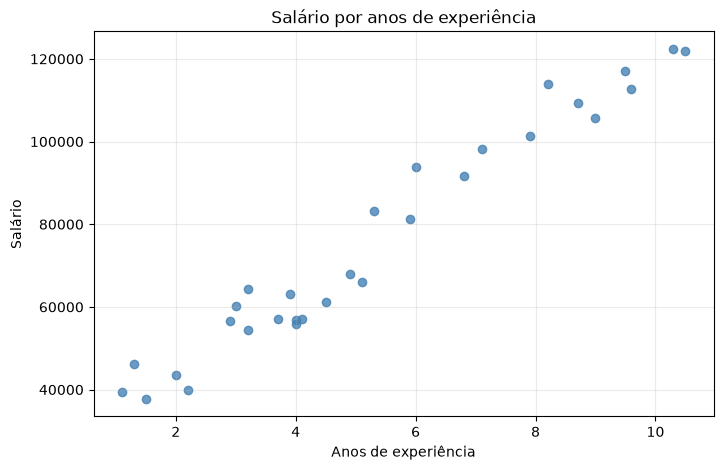

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(data["YearsExperience"], data["Salary"], color="steelblue", alpha=0.8)
plt.xlabel("Anos de experiência")
plt.ylabel("Salário")
plt.title("Salário por anos de experiência")
plt.grid(alpha=0.25)
plt.show()

Pelo gráfico, observa-se uma tendência linear nos dados. Agora separamos as variáveis explicativa e resposta. O `test_size=0.2` reserva 20% das observações para teste, enquanto `random_state=42` torna a divisão reproduzível.

In [5]:
X = data[["YearsExperience"]]
y = data["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Observações de treino: {len(X_train)}")
print(f"Observações de teste: {len(X_test)}")

Observações de treino: 24
Observações de teste: 6


A regressão é treinada com `X_train` e `y_train`. O intercepto é $\hat{\beta}_0$ e o coeficiente de `YearsExperience` é $\hat{\beta}_1$.

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

intercept = linear_model.intercept_
slope = linear_model.coef_[0]

print(f"Intercepto (B0): {intercept:.2f}")
print(f"Inclinação para YearsExperience (B1): {slope:.2f}")

Intercepto (B0): 25321.58
Inclinação para YearsExperience (B1): 9423.82


As métricas abaixo são calculadas separadamente. Comparar treino e teste ajuda a verificar se o desempenho se mantém em dados não vistos.

In [7]:
train_predictions = linear_model.predict(X_train)
test_predictions = linear_model.predict(X_test)

metrics = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_train, train_predictions),
            mean_absolute_error(y_test, test_predictions),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_train, train_predictions)),
            np.sqrt(mean_squared_error(y_test, test_predictions)),
        ],
        "R^2": [
            r2_score(y_train, train_predictions),
            r2_score(y_test, test_predictions),
        ],
    },
    index=["Treino", "Teste"],
)

metrics.round(2)

,MAE,RMSE,R^2
Treino,4221.05,5205.98,0.96
Teste,6286.45,7059.04,0.90


A reta aprendida é comparada com o gráfico de pontos dos dados de treino e de teste.

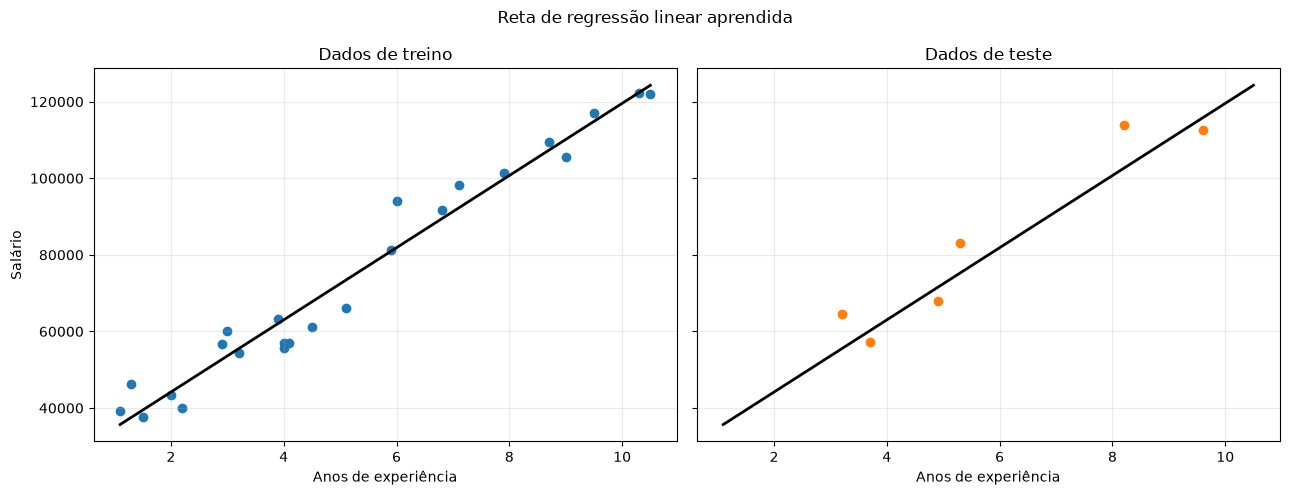

In [8]:
line_x = pd.DataFrame({"YearsExperience": np.linspace(X["YearsExperience"].min(), X["YearsExperience"].max(), 100)})
line_y = linear_model.predict(line_x)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].scatter(X_train["YearsExperience"], y_train, color="tab:blue")
axes[0].plot(line_x["YearsExperience"], line_y, color="black", linewidth=2)
axes[0].set_title("Dados de treino")
axes[0].set_xlabel("Anos de experiência")
axes[0].set_ylabel("Salário")
axes[0].grid(alpha=0.25)

axes[1].scatter(X_test["YearsExperience"], y_test, color="tab:orange")
axes[1].plot(line_x["YearsExperience"], line_y, color="black", linewidth=2)
axes[1].set_title("Dados de teste")
axes[1].set_xlabel("Anos de experiência")
axes[1].grid(alpha=0.25)

fig.suptitle("Reta de regressão linear aprendida")
plt.tight_layout()
plt.show()

Para testar o parâmetro $B_1$, usamos $H_0: \beta_1=0$ contra $H_1: \beta_1\neq 0$. O cálculo usa somente o treino, pois foi nele que os parâmetros foram estimados.

In [9]:
x_train_values = X_train["YearsExperience"].to_numpy()
train_residuals = y_train.to_numpy() - train_predictions

sample_size = len(x_train_values)
degrees_of_freedom = sample_size - 2
sum_squared_errors = np.sum(train_residuals**2)
error_standard_deviation = np.sqrt(sum_squared_errors / degrees_of_freedom)
x_variation = np.sum((x_train_values - x_train_values.mean()) ** 2)
slope_standard_error = error_standard_deviation / np.sqrt(x_variation)

t_statistic = slope / slope_standard_error
p_value = 2 * stats.t.sf(abs(t_statistic), df=degrees_of_freedom)
alpha = 0.05

print(f"Estimativa de B1: {slope:.4f}")
print(f"Erro-padrão de B1: {slope_standard_error:.4f}")
print(f"Estatística t: {t_statistic:.4f}")
print(f"p-valor: {p_value:.6g}")

if p_value <= alpha:
    print("Decisão: rejeitar H0 ao nível de significância de 5%.")
    print("Há evidência estatística de que B1 é diferente de zero.")
else:
    print("Decisão: não rejeitar H0 ao nível de significância de 5%.")
    print("Não há evidência estatística suficiente de que B1 seja diferente de zero.")

Estimativa de B1: 9423.8153
Erro-padrão de B1: 385.2332
Estatística t: 24.4626
p-valor: 1.9058e-17
Decisão: rejeitar H0 ao nível de significância de 5%.
Há evidência estatística de que B1 é diferente de zero.


Os resíduos são $e_i=y_i-\hat{y}_i$. Um padrão nos resíduos, como um desenho de "U", uma parábola ou um funil (abrindo ou fechando), pode indicar que a relação não é bem representada por uma reta (não-linearidade) ou que a variância dos erros não é constante.

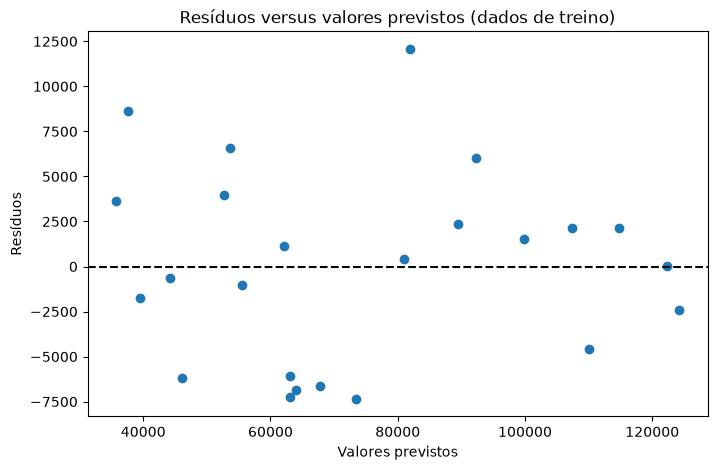

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(train_predictions, train_residuals)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos versus valores previstos (dados de treino)")
plt.show()

O gráfico mostra resíduos distribuídos acima e abaixo de zero, sem um padrão curvo ou formato de funil evidente. Isso sugere que a relação linear e a variância constante são razoáveis, embora existam alguns erros grandes que podem indicar observações atípicas.

## 14. Exemplo prático simples com Gradiente Descendente

Aqui, será desenvolvido um exemplo semelhante ao exemplo da seção anterior, mas sem dividir em treino e teste e utilizando o método do Gradiente Descendente descrito em **5.6**.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
data_path = Path("../data/salary_data.csv")
df = pd.read_csv(data_path)

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


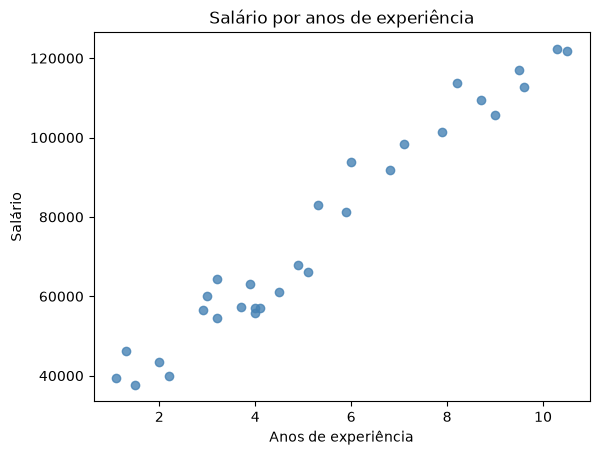

In [13]:
X = df["YearsExperience"].to_numpy()
Y = df["Salary"].to_numpy()

plt.scatter(X, Y, color="steelblue", alpha=0.8)
plt.xlabel("Anos de experiência")
plt.ylabel("Salário")
plt.title("Salário por anos de experiência")
plt.show()

A função de custo será definida.

In [14]:
def cost_function(x, y, b0, b1):
    n = len(x)
    cost_sum = 0

    for i in range(n):
        error_squared = (y[i] - (b0 + b1 * x[i])) ** 2
        cost_sum += error_squared

    return (1/(2 * n)) * cost_sum

Agora, o vetor gradiente será definido.

In [15]:
def gradient_vector(x, y, b0, b1):
    n = len(x)
    sum_dj_db0 = 0
    sum_dj_db1 = 0

    for i in range(n):
        error = y[i] - (b0 + b1 * x[i])
        sum_dj_db0 += error
        sum_dj_db1 += x[i] * error

    dj_db0 = (-1 / n) * sum_dj_db0
    dj_db1 = (-1 / n) * sum_dj_db1
    return np.array([dj_db0, dj_db1])

Por fim, definimos a função gradiente descendente, com os parâmetros b0 e b1 sendo arbitrariamente inicializados com valor 0.

In [16]:
def gradient_descent(x, y, learning_rate, iterations):
    b0 = 0
    b1 = 0
    costs = [cost_function(x, y, b0, b1)]

    print(f"Iteração: 0 - Custo: {costs[0]} - b0: {b0} - b1: {b1}")

    for i in range(iterations):
        dj_db0, dj_db1 = gradient_vector(x, y, b0, b1)

        b0 = b0 - learning_rate * dj_db0
        b1 = b1 - learning_rate * dj_db1

        cost = cost_function(x, y, b0, b1)
        costs.append(cost)
        print(f"Iteração: {i + 1} - Custo: {cost} - b0: {b0} - b1: {b1}")

    return b0, b1, costs

Agora, testaremos o algoritmo nos dados carregados.

In [17]:
learning_rate = 0.01
iterations = 10000

b_0, b_1, costs = gradient_descent(X, Y, learning_rate, iterations)
print(f"Intercepto (b0): {b_0:.4f} - Inclinação (b1): {b_1:.4f}")

Iteração: 0 - Custo: 3251477635.366667 - b0: 0 - b1: 0
Iteração: 1 - Custo: 1344612525.8413548 - b0: 760.03 - b1: 4773.987
Iteração: 2 - Custo: 582933639.1249903 - b0: 1258.8018573999998 - b1: 7788.160088166667
Iteração: 3 - Custo: 278595825.9816312 - b0: 1592.4329328080776 - b1: 9690.227091055453
Iteração: 4 - Custo: 156901936.81054005 - b0: 1821.6645373752503 - b1: 10889.506030597111
Iteração: 5 - Custo: 108149191.53202362 - b0: 1984.882138242438 - b1: 11644.664832824514
Iteração: 6 - Custo: 88526795.5063979 - b0: 2106.3434587426045 - b1: 12119.168311256937
Iteração: 7 - Custo: 80538511.12387824 - b0: 2201.3782145503933 - b1: 12416.317808711374
Iteração: 8 - Custo: 77197055.8093798 - b0: 2279.674079502025 - b1: 12601.394448807383
Iteração: 9 - Custo: 75711992.7100282 - b0: 2347.353246993706 - b1: 12715.65253207105
Iteração: 10 - Custo: 74968933.0700283 - b0: 2408.284709986394 - b1: 12785.16264257986
Iteração: 11 - Custo: 74522833.02695376 - b0: 2464.9135544774535 - b1: 12826.40003655

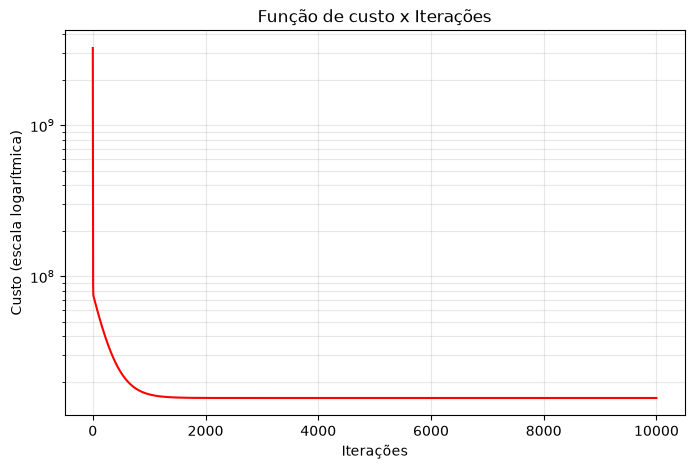

In [18]:
plt.figure(figsize=(8, 5))
plt.semilogy(range(len(costs)), costs, color="red")
plt.xlabel("Iterações")
plt.ylabel("Custo (escala logarítmica)")
plt.title("Função de custo x Iterações")
plt.grid(True, which="both", alpha=0.3)
plt.show()

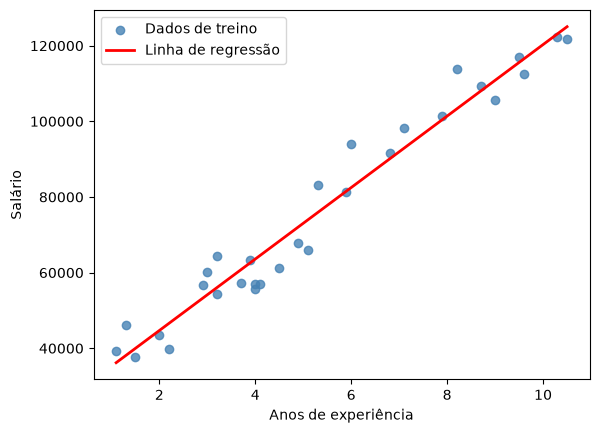

In [19]:
x_line = np.linspace(X.min(), X.max(), 100)
y_line = b_0 + b_1 * x_line
plt.scatter(X, Y, color="steelblue", label="Dados de treino", alpha=0.8)
plt.plot(x_line, y_line, color="red", linewidth=2, label="Linha de regressão")
plt.xlabel("Anos de experiência")
plt.ylabel("Salário")
plt.legend()
plt.show()

## 15. Conclusão

A Regressão Linear estima parâmetros por meio de uma função de custo, buscando os valores de parâmetros que minimizam a soma dos erros quadráticos (a função de custo). Na forma simples, isso produz as fórmulas de $\hat{\beta}_1$ e $\hat{\beta}_0$; em problemas maiores (com mais de uma variável explicativa), a mesma ideia pode ser expressa por álgebra matricial ou otimização.

A técnica reúne conceitos fundamentais de Machine Learning: variáveis explicativas e resposta, treinamento, generalização, resíduos, métricas e avaliação em dados não vistos. Seu uso adequado exige compreender os dados, interpretar os resultados e reconhecer quando as previsões podem falhar.